# **Projeto de Graduação em Computação II [2026-Q1]**

Universidade Federal do ABC

Orientador Carlos da Silva dos Santos

### **EQUIPE**

---

Caio Cardoso Dos Santos - RA: 11202021632

Victor Ravazio de Lima - RA: 11201920941

### **IMPLEMENTAÇÃO**
---

In [1]:
# modulo para importar dataset a partir de um link
!pip install gdown

In [2]:
#Bibliotecas
import pandas as pd
import numpy as np
from google.colab import files
import gdown
import matplotlib.pyplot as plt
import random
import seaborn as sns

In [3]:
#Variaveis de controle
num_anotados = 150

# **Pares Tweets-Reply**

In [4]:
# baixando dataset para o collab
import gdown

file_class_caio = "1ZmM9T3weOc5wZ2FoYgmR9fibQU8QqbV4"
file_class_victor = "1QJ6-CqpWSG1L_A0F1OOdDyf057JVMdWe"
url_1 = f"https://drive.google.com/uc?id={file_class_caio}"
url_2 = f"https://drive.google.com/uc?id={file_class_victor}"

gdown.download(url_1, "Mandetta_caio.csv", quiet=False)
gdown.download(url_2, "Mandetta_victor.csv", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1ZmM9T3weOc5wZ2FoYgmR9fibQU8QqbV4
To: /content/Mandetta_caio.csv
100%|██████████| 503k/503k [00:00<00:00, 56.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1QJ6-CqpWSG1L_A0F1OOdDyf057JVMdWe
To: /content/Mandetta_victor.csv
100%|██████████| 503k/503k [00:00<00:00, 33.1MB/s]


'Mandetta_victor.csv'

In [5]:
#carregando o dataset
df_caio = pd.read_csv ("Mandetta_caio.csv")
df_victor = pd.read_csv ("Mandetta_victor.csv")

In [6]:
#numero total de instancias no dataset
df_caio.shape

(1500, 7)

In [7]:
#numero total de instancias no dataset
df_victor.shape

(1500, 7)

In [8]:
df_caio.head(20)

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Conflict,Tipo
0,Caralho to indignado que o Mandetta saiu antes...,Porra aí é foda mano,2,0.555224,0.444776,0.0,Incerta
1,Como brasileiro agradeço o ministro Mandetta p...,"E lamento, por saber que as pessoas não são le...",2,0.554458,0.445541,0.0,Incerta
2,"Bolsonaro demitiu Mandetta por ciúme, inveja e...","O pico da epidemia não será em maio e junho, s...",1,0.545619,0.454381,1.0,Incerta
3,"Em sua despedida, Mandetta defende a vida, o S...",Mais são compatíveis com o Mandetta,1,0.567799,0.432201,0.0,Incerta
4,Acabo de ouvir do presidente Jair Bolsonaro o ...,"O novo ministro parece não ser ruim , tomara q...",2,0.532623,0.467377,0.0,Incerta
5,Bolsonaro acaba de demitir Mandetta do Ministé...,quantos anos vocês fariam em 2021? kk me: 16 k,2,0.459356,0.540644,0.0,Incerta
6,"""E o Mandetta, a linha dele, como médico, era ...","Onde já se viu, um médico, ter a linha voltada...",2,0.506886,0.493114,0.0,Incerta
7,Agradeço ao Ministro Mandetta pelo trabalho e ...,Que assim seja,2,0.542998,0.457002,0.0,Incerta
8,Hoje lemos na imprensa que o DEM quer aproveit...,Que popularidade? Só se for dos ratos do esgot...,2,0.468583,0.531417,1.0,Incerta
9,Acabo de ouvir do presidente Jair Bolsonaro o ...,Obrigado pelo trabalho prestado a toda populaç...,2,0.553382,0.446618,0.0,Incerta


In [9]:
df_victor.head(20)

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Conflict,Tipo
0,Caralho to indignado que o Mandetta saiu antes...,Porra aí é foda mano,2,0.555224,0.444776,0.0,Incerta
1,Como brasileiro agradeço o ministro Mandetta p...,"E lamento, por saber que as pessoas não são le...",2,0.554458,0.445541,0.0,Incerta
2,"Bolsonaro demitiu Mandetta por ciúme, inveja e...","O pico da epidemia não será em maio e junho, s...",1,0.545619,0.454381,1.0,Incerta
3,"Em sua despedida, Mandetta defende a vida, o S...",Mais são compatíveis com o Mandetta,1,0.567799,0.432201,0.0,Incerta
4,Acabo de ouvir do presidente Jair Bolsonaro o ...,"O novo ministro parece não ser ruim , tomara q...",2,0.532623,0.467377,0.0,Incerta
5,Bolsonaro acaba de demitir Mandetta do Ministé...,quantos anos vocês fariam em 2021? kk me: 16 k,2,0.459356,0.540644,0.0,Incerta
6,"""E o Mandetta, a linha dele, como médico, era ...","Onde já se viu, um médico, ter a linha voltada...",2,0.506886,0.493114,0.0,Incerta
7,Agradeço ao Ministro Mandetta pelo trabalho e ...,Que assim seja,2,0.542998,0.457002,0.0,Incerta
8,Hoje lemos na imprensa que o DEM quer aproveit...,Que popularidade? Só se for dos ratos do esgot...,2,0.468583,0.531417,1.0,Incerta
9,Acabo de ouvir do presidente Jair Bolsonaro o ...,Obrigado pelo trabalho prestado a toda populaç...,2,0.553382,0.446618,0.0,Incerta


In [10]:
df_remaining = df_caio.iloc[num_anotados:,:]
df_caio = df_caio.iloc[:num_anotados,:]
df_victor = df_victor.iloc[:num_anotados,:]

In [11]:
df_caio

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Conflict,Tipo
0,Caralho to indignado que o Mandetta saiu antes...,Porra aí é foda mano,2,0.555224,0.444776,0.0,Incerta
1,Como brasileiro agradeço o ministro Mandetta p...,"E lamento, por saber que as pessoas não são le...",2,0.554458,0.445541,0.0,Incerta
2,"Bolsonaro demitiu Mandetta por ciúme, inveja e...","O pico da epidemia não será em maio e junho, s...",1,0.545619,0.454381,1.0,Incerta
3,"Em sua despedida, Mandetta defende a vida, o S...",Mais são compatíveis com o Mandetta,1,0.567799,0.432201,0.0,Incerta
4,Acabo de ouvir do presidente Jair Bolsonaro o ...,"O novo ministro parece não ser ruim , tomara q...",2,0.532623,0.467377,0.0,Incerta
...,...,...,...,...,...,...,...
145,Moro: técnico; Guedes: técnico; Pontes: técnic...,Mandetta não é técnico por qual critério? No m...,1,0.570573,0.429427,1.0,Incerta
146,Mandetta fica como prova didática de que nem p...,Definição mais cirúrgica que li sobre o papel ...,1,0.528528,0.471472,0.0,Incerta
147,No meio de uma pandemia mundial o bonitão demi...,Bolsonaro é um rato oportunista. Demitiu Mande...,0,0.490989,0.509011,0.0,Incerta
148,Vi o vídeo dos últimos minutos do Mandetta na ...,Já eu tive a experiência contrária: Xingar ant...,2,0.552303,0.447697,0.0,Incerta


In [12]:
df_victor

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Conflict,Tipo
0,Caralho to indignado que o Mandetta saiu antes...,Porra aí é foda mano,2,0.555224,0.444776,0.0,Incerta
1,Como brasileiro agradeço o ministro Mandetta p...,"E lamento, por saber que as pessoas não são le...",2,0.554458,0.445541,0.0,Incerta
2,"Bolsonaro demitiu Mandetta por ciúme, inveja e...","O pico da epidemia não será em maio e junho, s...",1,0.545619,0.454381,1.0,Incerta
3,"Em sua despedida, Mandetta defende a vida, o S...",Mais são compatíveis com o Mandetta,1,0.567799,0.432201,0.0,Incerta
4,Acabo de ouvir do presidente Jair Bolsonaro o ...,"O novo ministro parece não ser ruim , tomara q...",2,0.532623,0.467377,0.0,Incerta
...,...,...,...,...,...,...,...
145,Moro: técnico; Guedes: técnico; Pontes: técnic...,Mandetta não é técnico por qual critério? No m...,1,0.570573,0.429427,1.0,Incerta
146,Mandetta fica como prova didática de que nem p...,Definição mais cirúrgica que li sobre o papel ...,1,0.528528,0.471472,0.0,Incerta
147,No meio de uma pandemia mundial o bonitão demi...,Bolsonaro é um rato oportunista. Demitiu Mande...,0,0.490989,0.509011,0.0,Incerta
148,Vi o vídeo dos últimos minutos do Mandetta na ...,Já eu tive a experiência contrária: Xingar ant...,2,0.552303,0.447697,1.0,Incerta


In [13]:
confusion = np.zeros((3,3))

idx_diff = []  # lista com os índices i onde as classificações diferem

In [14]:
for i in range(df_caio.shape[0]):
  caio = int(df_caio.iloc[i]["Conflict"])
  victor = int(df_victor.iloc[i]["Conflict"])

  # mapeia -1 para 2 para a matriz 3x3
  row = 2 if caio == -1 else caio
  col = 2 if victor == -1 else victor

  confusion[row][col] += 1

  # se são diferentes (fora da diagonal principal)
  if row != col:
    idx_diff.append(i)

In [15]:
confusion

array([[94.,  4.,  3.],
       [ 7., 38.,  3.],
       [ 0.,  0.,  1.]])

In [16]:
idx_diff

[11, 16, 17, 28, 32, 53, 64, 81, 99, 100, 117, 122, 129, 137, 141, 144, 148]

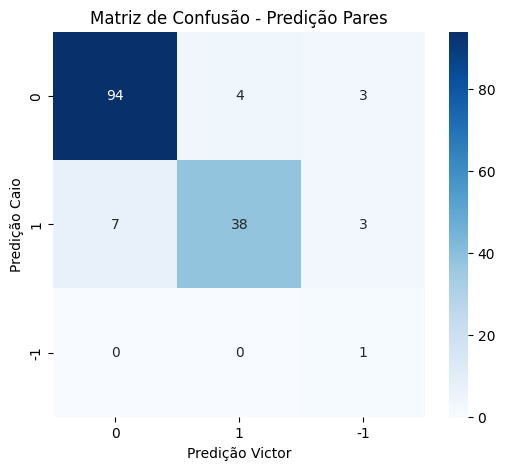

In [17]:
labels = ["0", "1", "-1"] # classes

plt.figure(figsize=(6,5))
sns.heatmap(confusion, annot=True, fmt=".0f", cmap="Blues", xticklabels=labels, yticklabels=labels) #desenha a matriz de confusão como uma "matriz de calor"

plt.xlabel("Predição Victor")
plt.ylabel("Predição Caio")
plt.title("Matriz de Confusão - Predição Pares")
plt.show()

In [18]:
mapa = {-1: "Indeterminado", 0: "Não Conflito", 1: "Conflito"}

for i in range(len(idx_diff)):
  print("Tweet 1: ", df_caio.loc[idx_diff[i], "tweet_1"])
  print("Tweet 2: ", df_caio.loc[idx_diff[i], "tweet_2"])
  print("Classificação Caio: ", mapa[int(df_caio.loc[idx_diff[i], "Conflict"])])
  print("Classificação Victor: ", mapa[int(df_victor.loc[idx_diff[i], "Conflict"])])
  print()

Tweet 1:  A maioria esmagadora dos brasileiros é contrária à demissão de Mandetta: 76,2% dos entrevistados discordam do afastamento do ministro da Saúde, segundo pesquisa realizada pelo Atlas Político. Vc concorda com o resultado da pesquisa?   via
Tweet 2:  Pesquisa de merda! Mandetta demorou a ser demitido - péssimo, politiqueiro e incompetente... só não vê quem não quer ou, quem assiste e acredita na globo!
Classificação Caio:  Conflito
Classificação Victor:  Não Conflito

Tweet 1:  Bolsonaro demitiu Mandetta porque ele seguia as orientações da OMS e não negava a ciência. Que tipo de médico aceita assumir um ministério da saúde assim? Esse vídeo é uma prévia do que pode estar nos esperando num futuro próximo. Precisamos tirar Bolsonaro para salvar o país.
Tweet 2:  Não se enganem pelo tom: é o procedimento  Não há nada na fala que desqualifique o Teich   É o procedimento eo que reza a ética médica
Classificação Caio:  Não Conflito
Classificação Victor:  Conflito

Tweet 1:  Você é be

# **Criando Dataset das divergencias**

In [19]:
div_mandetta = df_caio.iloc[idx_diff].drop('Conflict', axis=1)
div_mandetta['Conflict_caio'] = df_caio['Conflict'].iloc[idx_diff].astype(int)
div_mandetta['Conflict_victor'] = df_victor['Conflict'].iloc[idx_diff].astype(int)
div_mandetta['Conflict'] = np.nan

In [20]:
div_mandetta.shape

(17, 9)

In [21]:
div_mandetta_final = div_mandetta.drop(columns=['Conflict_caio', 'Conflict_victor'])
div_mandetta_final

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Tipo,Conflict
11,A maioria esmagadora dos brasileiros é contrár...,Pesquisa de merda! Mandetta demorou a ser demi...,1,0.565373,0.434627,Incerta,NaN
16,Bolsonaro demitiu Mandetta porque ele seguia a...,Não se enganem pelo tom: é o procedimento Não...,2,0.540527,0.459473,Incerta,NaN
17,"Você é bem inocente, né? Já ouviu falar de psi...","O Bolsonaro demitiu o Mandetta, vai entrar um ...",1,0.421403,0.578597,Incerta,NaN
28,Bolsonaro diz que podem perguntar pq decidiu s...,Ai como vocé é burro!,2,0.512396,0.487604,Incerta,NaN
32,"De acordo com a nova Pesquisa do Atlas, Mandet...",VAMOS FAZER ESSES IMUNDOS PASSAREM VERGONHA!!!!,2,0.438529,0.561471,Incerta,NaN
53,Quem sabe com a saída do Mandetta os postos de...,e pq vc não esta defendendo isolamento social?...,0,0.120758,0.879242,Alta,NaN
64,Bolsonaro segue na sua cruzada assassina contr...,"Mandetta, não apoiava a verticalização do isol...",0,0.142991,0.857009,Alta,NaN
81,"Vale lembrar: Bolsonaro demitiu Mandetta, mas...","""Luiz Henrique Mandetta como ministro da Saúde...",1,0.990809,0.009191,Random,NaN
99,mandetta cumplice de maia em seu projeto de po...,"Infelizmente apertem o cintos e rezem, orem ca...",0,0.978347,0.021653,Random,NaN
100,O elogio emocionado de Fernando Haddad a Henri...,"Ô LOCO MÊU!!! Receber elogio do “adad”, cheira...",2,0.528972,0.471028,Incerta,NaN


In [22]:
div_mandetta_final.to_csv("divergencias_mandetta_exploratoria.csv", index=False, encoding="utf-8")
files.download("divergencias_mandetta_exploratoria.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Criando Dataset das Convergencias**




In [23]:
conv_mandetta = df_caio.drop(index=idx_diff, errors='ignore')

In [24]:
conv_mandetta.shape

(133, 7)

In [25]:
conv_mandetta

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Conflict,Tipo
0,Caralho to indignado que o Mandetta saiu antes...,Porra aí é foda mano,2,0.555224,0.444776,0.0,Incerta
1,Como brasileiro agradeço o ministro Mandetta p...,"E lamento, por saber que as pessoas não são le...",2,0.554458,0.445541,0.0,Incerta
2,"Bolsonaro demitiu Mandetta por ciúme, inveja e...","O pico da epidemia não será em maio e junho, s...",1,0.545619,0.454381,1.0,Incerta
3,"Em sua despedida, Mandetta defende a vida, o S...",Mais são compatíveis com o Mandetta,1,0.567799,0.432201,0.0,Incerta
4,Acabo de ouvir do presidente Jair Bolsonaro o ...,"O novo ministro parece não ser ruim , tomara q...",2,0.532623,0.467377,0.0,Incerta
...,...,...,...,...,...,...,...
143,Desejo ao Dr. Nelson Teich novo Ministro da Sa...,eu tava no cagaço do dia que eu ia ler essa no...,0,0.404341,0.595659,0.0,Incerta
145,Moro: técnico; Guedes: técnico; Pontes: técnic...,Mandetta não é técnico por qual critério? No m...,1,0.570573,0.429427,1.0,Incerta
146,Mandetta fica como prova didática de que nem p...,Definição mais cirúrgica que li sobre o papel ...,1,0.528528,0.471472,0.0,Incerta
147,No meio de uma pandemia mundial o bonitão demi...,Bolsonaro é um rato oportunista. Demitiu Mande...,0,0.490989,0.509011,0.0,Incerta


In [26]:
#adicionando as classificações do professor
#file_class_mandetta_prof = "1FSUrpSaiBAp5Gho-CsEw6kse3q4wCB8B"
#url = f"https://drive.google.com/uc?id={file_class_mandetta_prof}"
#gdown.download(url, "mandetta_class_prof.csv", quiet=False)
#df_class_prof = pd.read_csv ("mandetta_class_prof.csv")

In [27]:
#df_class_prof

In [28]:
#df_desempate = div_mandetta.merge(df_class_prof, on=['tweet_1', 'tweet_2'], how='inner')
#df_desempate = df_desempate.drop(columns=['Conflict_x', 'Class_y'])
#df_desempate = df_desempate.rename(columns={'Class_x': 'Class', 'Conflict_y': 'Conflict_prof'})
#df_desempate

In [29]:
def resolver_conflito(row):
    prof = row['Conflict_prof']
    caio = row['Conflict_caio']
    victor = row['Conflict_victor']

    if prof == caio or prof == victor:
        return prof
    else:
        return -1

#df_desempate['Conflict'] = df_desempate.apply(resolver_conflito, axis=1)

In [30]:
#df_desempate

In [31]:
#df_desempate = df_desempate.drop(columns=['Conflict_caio', 'Conflict_victor', 'Conflict_prof'])
#df_desempate

In [32]:
#conv_mandetta = pd.concat([conv_contas_suspensas, df_desempate], ignore_index=True, axis = 0)
#conv_mandetta

In [33]:
conv_mandetta.to_csv("convergencias_mandetta_exploratoria.csv", index=False, encoding="utf-8")
files.download("convergencias_mandetta_exploratoria.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Dataset com pares não anotados**

In [34]:
remainig_df = df_remaining.drop('Conflict', axis=1)
remainig_df

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Tipo
150,Mandetta foi escolhido Ministro com a missão d...,acho ingênuo achar que Mandetta virou pro-SUS ...,2,0.170198,0.829802,Alta
151,"Em sua despedida, Mandetta defende a vida, o S...",O SUS? RAPAZ,2,0.199062,0.800938,Alta
152,"Em sua despedida, Mandetta defende a vida, o S...",Compatível mesmo é o rombo bilionário que o PT...,2,0.109780,0.890220,Alta
153,"Após a saída do Mandetta, quem deveria ser o p...","deixe nosso presidente governar, vc é um bosta...",2,0.185385,0.814615,Alta
154,"Em sua despedida, Mandetta defende a vida, o S...",Inacreditável que o Haddad romantiza o verdade...,2,0.150742,0.849258,Alta
...,...,...,...,...,...,...
1495,"Em sua despedida, Mandetta defende a vida, o S...",O próximo é pior. Mas onde além do discurso o ...,1,0.798402,0.201598,Random
1496,URGENTE: Bolsonaro demite Mandetta do Ministér...,gente mas é uma anta msm,2,0.988627,0.011373,Random
1497,"Bolsonaro, discursa após demitir Mandetta. Nem...",O Brasil está livre de um dos seus piores pesa...,0,0.989665,0.010335,Random
1498,"Em sua despedida, Mandetta defende a vida, o S...",É por essas coisas que a esquerda vai continua...,2,0.290527,0.709473,Random


In [35]:
remainig_df.to_csv("mandetta_nao_anotado_exploratoria.csv", index=False, encoding="utf-8")
files.download("mandetta_nao_anotado_exploratoria.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>